# Using IDyOM with _melody-features_

The package includes scripts to install and run [IDyOM](https://github.com/mtpearce/idyom), a tool for constructing variable-order Markov models that represent the conditional probability distribution of musical events ([Guan et al., 2022](https://joss.theoj.org/papers/10.21105/joss.04738); [Pearce, 2005](https://www.marcus-pearce.com/assets/papers/Pearce2005.pdf)).

IDyOM can be run as part of the top-level `get_all_features()` function, but some users may prefer to skip the other feature values and run IDyOM alone. This notebook demonstrates how this may be achieved.

## Setup

In [4]:
from melody_features import idyom_interface as idyom
print(f"IDyOM installed and ready to use: {idyom.is_idyom_installed()}")

IDyOM installed and ready to use: True


If this cell returned `False`, you'll need to install IDyOM before continuing:

In [ ]:
from melody_features.idyom.interface import install_idyom
install_idyom()

This function should take care of all the install, provided you have the package manager relevant to your OS installed.

## Running IDyOM

First, we specify the behaviour we want IDyOM to follow and provide a directory that contains the MIDI files we want to analyse:

In [14]:
import shutil
import tempfile
from pathlib import Path

from melody_features import essen_corpus

target_melody = essen_corpus / "elsass15.mid"
input_path = Path(tempfile.mkdtemp(prefix="idyom_elsass15_"))
shutil.copy2(target_melody, input_path / "elsass15.mid")
input_path = str(input_path)

experiment_name = "elsass15"
target_viewpoints = ["cpitch"]
source_viewpoints = ["cpint"]
ppm_order = None
detail = 3
models = ":stm"

print(f"IDyOM input directory: {input_path}")
print(f"Copied: {target_melody.name}")

IDyOM input directory: /var/folders/kd/t7g208g97fgcw1v9q3__l3b40000gn/T/idyom_elsass15_zlzl_jtd
Copied: elsass15.mid


In [15]:
idyom.run_idyom(input_path=input_path,
                experiment_name=experiment_name,
                target_viewpoints=target_viewpoints,
                source_viewpoints=source_viewpoints,
                ppm_order=ppm_order,
                detail=detail,
                models=models)

** Putting Test dataset files in experiment history folder. **
** No pretraining dataset detected. **
** running lisp script **
To load "clsql":
  Load 1 ASDF system:
    clsql
; Loading "clsql"

To load "idyom":
  Load 1 ASDF system:
    idyom
; Loading "idyom"
................

Inserting 1 compositions into database: dataset 66082526153109.
| Progress: -----------------------------------------------|
** Finished! **


'/Users/davidwhyatt/feature_set/demos/elsass15.dat'

This creates a `.dat` file corresponding to that IDyOM run.

In [17]:
import pandas as pd

idyom_data = pd.read_csv(f"{experiment_name}.dat", sep=r'\s+', header=0, na_values=["NA"])
idyom_data.head()

,dataset.id,melody.id,note.id,melody.name,vertint12,articulation,comma,voice,ornament,dyn,phrase,bioi,deltast,accidental,mpitch,cpitch,barlength,pulses,tempo,mode,keysig,dur,onset,cpitch.order.stm.cpint,cpitch.weight.stm.cpint,cpitch.probability,cpitch.ic,cpitch.entropy,cpitch.52,cpitch.53,cpitch.55,cpitch.57,cpitch.59,cpitch.60,cpitch.62,cpitch.64,probability,ic,entropy,information.gain
0,66082526153109,1,1,elsass15,NaN,0,0,1,0,90,0,0,0,NaN,NaN,55,96,4,120,0,0,12,0,0,1.0,0.125000,3.000000,3.000000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,3.000000,3.000000,NaN
1,66082526153109,1,2,elsass15,NaN,0,0,1,0,90,0,12,0,NaN,NaN,60,96,4,120,0,0,36,12,0,1.0,0.125000,3.000000,3.000000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,3.000000,3.000000,0.000000
2,66082526153109,1,3,elsass15,NaN,0,0,1,0,90,0,36,0,NaN,NaN,60,96,4,120,0,0,12,48,0,1.0,0.125000,3.000000,3.000000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,0.125000,3.000000,3.000000,0.000000
3,66082526153109,1,4,elsass15,NaN,0,0,1,0,90,0,12,0,NaN,NaN,55,96,4,120,0,0,24,60,0,1.0,0.083333,3.584963,2.617492,0.083333,0.083333,0.083333,0.083333,0.083333,0.416667,0.083333,0.083333,0.083333,3.584963,2.617492,0.294722
4,66082526153109,1,5,elsass15,NaN,0,0,1,0,90,0,24,0,NaN,NaN,60,96,4,120,0,0,12,84,0,1.0,0.263158,1.926000,2.748772,0.078947,0.078947,0.263158,0.078947,0.078947,0.263158,0.078947,0.078947,0.263158,1.926000,2.748772,0.176990


We can see that IDyOM was able to compute lots of interesting features, including the information content and entropy of this melody. 

Plotting information content allows us to see which moments of the melody were most surprising!

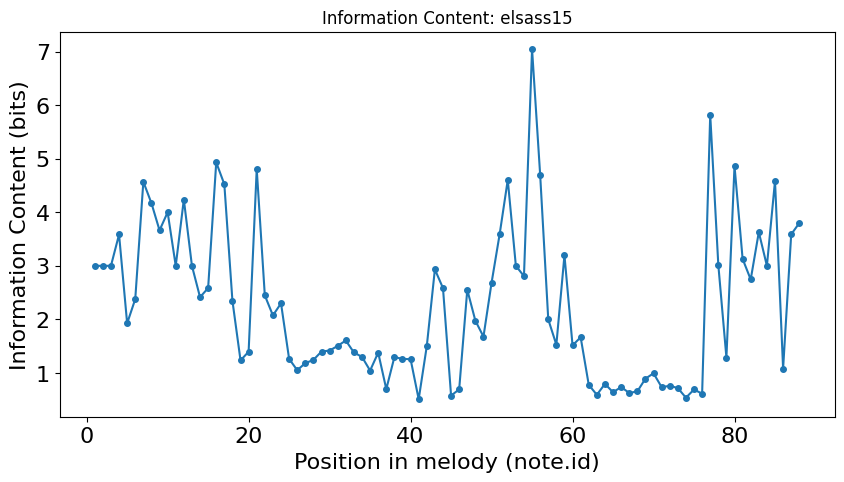

In [22]:
import matplotlib.pyplot as plt

dat_file = f"{experiment_name}.dat"
melody_name = idyom_data["melody.name"].unique()[0]

plt.figure(figsize=(10, 5))
plt.plot(idyom_data["note.id"], idyom_data["ic"], marker='o', markersize=4)
plt.xlabel("Position in melody (note.id)")
plt.ylabel("Information Content (bits)")
plt.title(f"Information Content: {melody_name}")
plt.show()



<sub>This notebook is inspired by material I put together for my undergrad teaching at the University of Cambridge: https://github.com/dmwhyatt/Part-IB-Expectation-IDyOM/blob/main/idyom.ipynb </sub>